In [1]:
!pip -q install -U kagglehub

In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import kagglehub

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
DATASET_HANDLE = "sanikamal/rock-paper-scissors-dataset"

dataset_path = kagglehub.dataset_download(
    DATASET_HANDLE,
    output_dir="/content/rps_data"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 452M/452M [00:25<00:00, 18.8MB/s]

Extracting files...


Dataset downloaded to:
/content/rps_data


In [4]:
DATASET_ROOT = Path(dataset_path)

def find_dataset_directory(root, directory_name):
    required_classes = {"rock", "paper", "scissors"}

    for path in root.rglob(directory_name):

        if not path.is_dir():
            continue

        subdirs = {
            item.name.lower()
            for item in path.iterdir()
            if item.is_dir()
        }

        if required_classes.issubset(subdirs):
            return path

    raise FileNotFoundError(
        f"Could not find '{directory_name}' directory "
        "containing rock, paper, scissors folders."
    )


TRAIN_DIR = find_dataset_directory(
    DATASET_ROOT,
    "train"
)

TEST_DIR = find_dataset_directory(
    DATASET_ROOT,
    "test"
)


print("Train directory:")
print(TRAIN_DIR)

print("\nTest directory:")
print(TEST_DIR)

Train directory:
/content/rps_data/Rock-Paper-Scissors/train

Test directory:
/content/rps_data/Rock-Paper-Scissors/test


In [5]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

In [6]:
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Class Names:")
print(class_names)

print("Number of Classes:")
print(len(class_names))

Found 2520 files belonging to 3 classes.
Using 2016 files for training.
Found 2520 files belonging to 3 classes.
Using 504 files for validation.
Class Names:
['paper', 'rock', 'scissors']
Number of Classes:
3


In [7]:
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    class_names=class_names,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 372 files belonging to 3 classes.


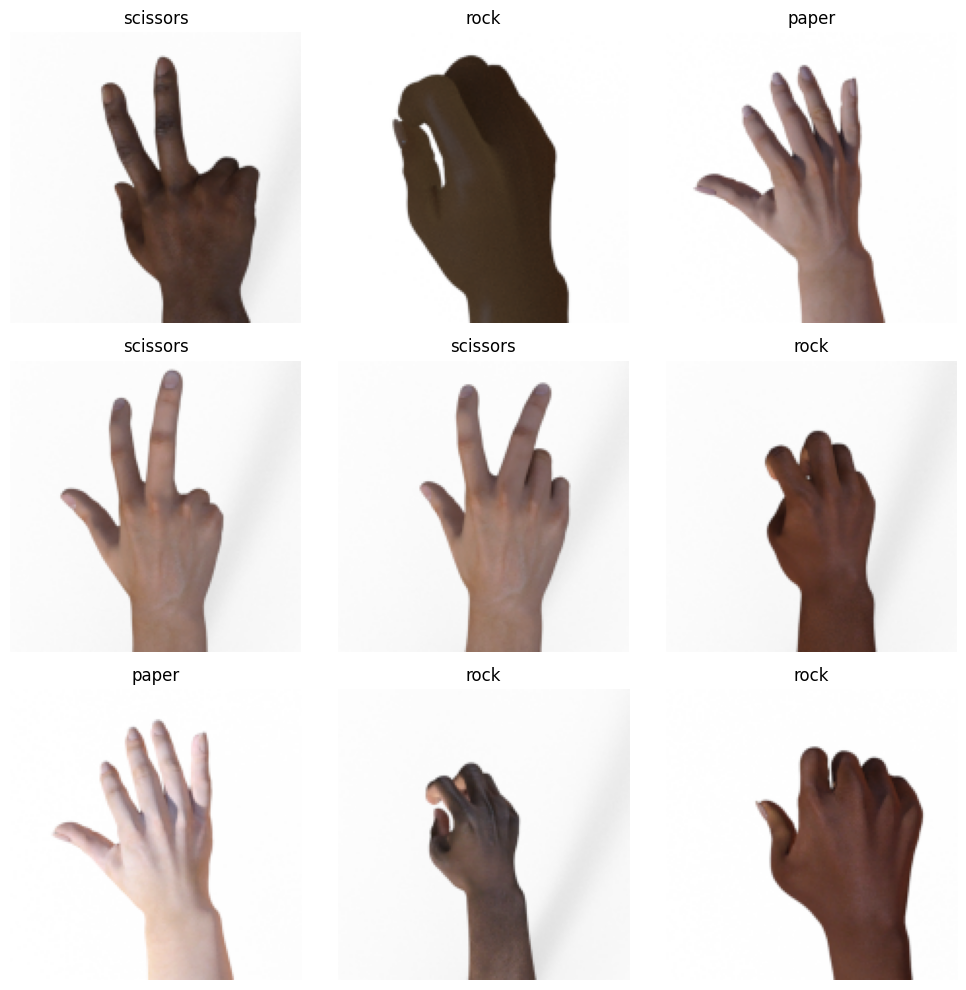

In [8]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [10]:
baseline_model = keras.Sequential([

    layers.Input(
        shape=(150, 150, 3)
    ),

    # 0~255 → 0~1
    layers.Rescaling(
        1.0 / 255
    ),

    # Convolution Block 1
    layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Block 2
    layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Block 3
    layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Classification
    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        3,
        activation="softmax"
    )
])


baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
BASELINE_EPOCHS = 15

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - accuracy: 0.7500 - loss: 0.5631 - val_accuracy: 0.9881 - val_loss: 0.0517
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9950 - loss: 0.0221 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 1.0000 - loss: 9.0072e-04 - val_accuracy: 1.0000 - val_loss: 4.2462e-04
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 1.0000 - loss: 2.8720e-04 - val_accuracy: 1.0000 - val_loss: 1.7346e-04
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 1.0000 - loss: 1.4193e-04 - val_accuracy: 1.0000 - val_loss: 1.3389e-04
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 1.0000 - loss: 9.8684e-05 - val_accuracy: 1.0000 - val_loss: 1.0361e-04
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 1.0000 - loss: 7.1495e-05 - val_accuracy: 1.0000 - val_loss: 7.1354e-05
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 1.000

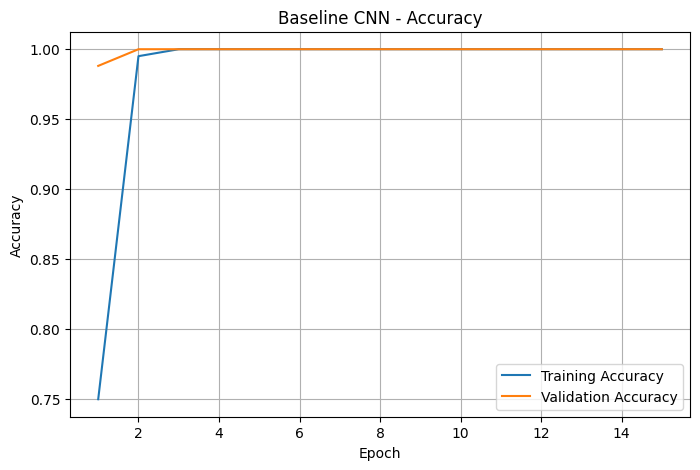

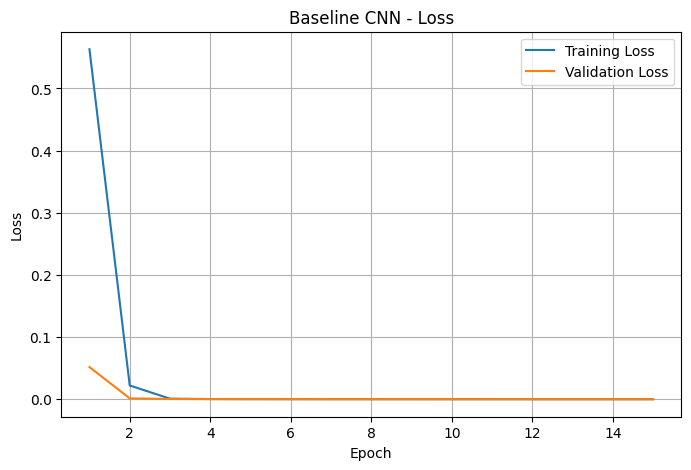

In [13]:
# ============================================================
# Baseline Model Training History
# ============================================================

baseline_history_data = baseline_history.history

baseline_epochs = range(
    1,
    len(baseline_history_data["accuracy"]) + 1
)

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_epochs,
    baseline_history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_epochs,
    baseline_history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_epochs,
    baseline_history_data["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_epochs,
    baseline_history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Loss")
plt.legend()
plt.grid()
plt.show()


In [14]:
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(
    test_ds
)

print(
    f"Baseline Test Loss: "
    f"{baseline_test_loss:.4f}"
)

print(
    f"Baseline Test Accuracy: "
    f"{baseline_test_accuracy:.4f}"
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.7339 - loss: 1.6576
Baseline Test Loss: 1.6576
Baseline Test Accuracy: 0.7339


In [15]:
data_augmentation = keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.1
    ),

    layers.RandomZoom(
        0.1
    )

])

In [16]:
improved_model = keras.Sequential([

    layers.Input(
        shape=(150, 150, 3)
    ),

    # Data Augmentation
    data_augmentation,

    # Normalization
    layers.Rescaling(
        1.0 / 255
    ),

    # Convolution Block 1
    layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Block 2
    layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Block 3
    layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    # Regularization
    layers.Dropout(
        0.5
    ),

    layers.Dense(
        3,
        activation="softmax"
    )
])


improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


model_checkpoint = keras.callbacks.ModelCheckpoint(
    "/content/best_rps_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [19]:
IMPROVED_EPOCHS = 30

improved_history = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=IMPROVED_EPOCHS,

    callbacks=[
        early_stopping,
        reduce_lr,
        model_checkpoint
    ]
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.5456 - loss: 0.9430 - val_accuracy: 0.9028 - val_loss: 0.2811 - learning_rate: 0.0010
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.8839 - loss: 0.3080 - val_accuracy: 0.9841 - val_loss: 0.0735 - learning_rate: 0.0010
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9405 - loss: 0.1719 - val_accuracy: 0.9583 - val_loss: 0.0764 - learning_rate: 0.0010
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.9489 - loss: 0.1603 - val_accuracy: 1.0000 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.9668 - loss: 0.0991 - val_accuracy: 1.0000 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9757 - loss: 0.0775 - val_accuracy: 0.9980 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9821 - loss: 0.0581 - val_

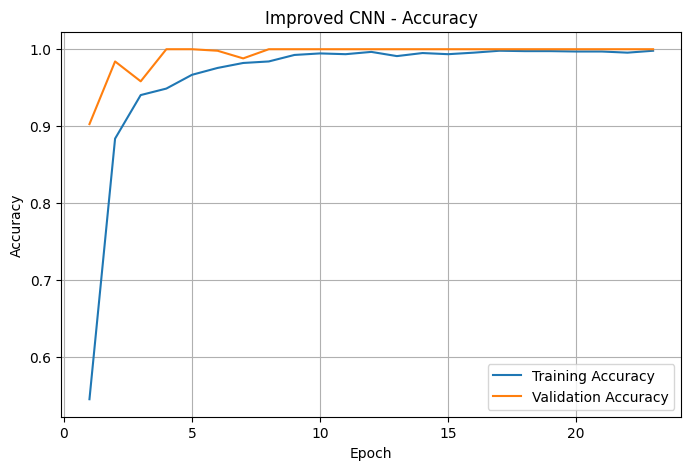

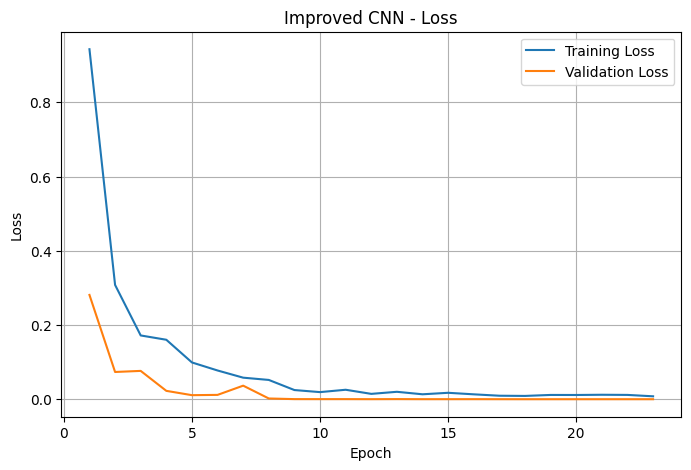

In [20]:
# ============================================================
# Improved Model Training History
# ============================================================

improved_history_data = improved_history.history

improved_epochs = range(
    1,
    len(improved_history_data["accuracy"]) + 1
)

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    improved_epochs,
    improved_history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    improved_epochs,
    improved_history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved CNN - Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    improved_epochs,
    improved_history_data["loss"],
    label="Training Loss"
)

plt.plot(
    improved_epochs,
    improved_history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved CNN - Loss")
plt.legend()
plt.grid()
plt.show()


In [21]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    test_ds
)


print(
    f"Improved Test Loss: "
    f"{improved_test_loss:.4f}"
)

print(
    f"Improved Test Accuracy: "
    f"{improved_test_accuracy:.4f}"
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.9489 - loss: 0.2626
Improved Test Loss: 0.2626
Improved Test Accuracy: 0.9489


In [22]:
print("=" * 50)

print("Baseline CNN")

print(
    f"Test Loss     : "
    f"{baseline_test_loss:.4f}"
)

print(
    f"Test Accuracy : "
    f"{baseline_test_accuracy:.4f}"
)


print()

print("Improved CNN")

print(
    f"Test Loss     : "
    f"{improved_test_loss:.4f}"
)

print(
    f"Test Accuracy : "
    f"{improved_test_accuracy:.4f}"
)

print("=" * 50)

Baseline CNN
Test Loss     : 1.6576
Test Accuracy : 0.7339

Improved CNN
Test Loss     : 0.2626
Test Accuracy : 0.9489


In [23]:
y_true = []
y_pred = []


for images, labels in test_ds:

    predictions = improved_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )


y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [24]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       paper       1.00      0.89      0.94       124
        rock       1.00      0.96      0.98       124
    scissors       0.87      1.00      0.93       124

    accuracy                           0.95       372
   macro avg       0.96      0.95      0.95       372
weighted avg       0.96      0.95      0.95       372



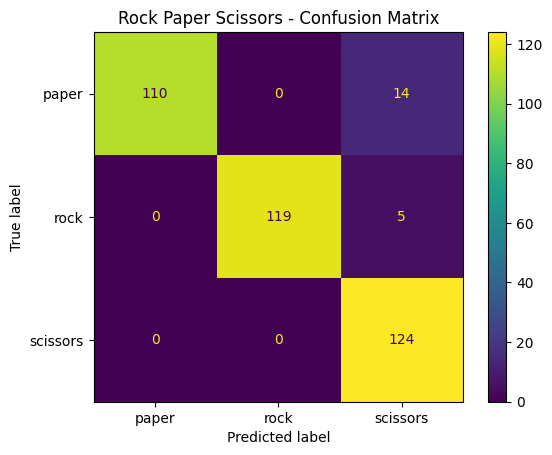

In [25]:
cm = confusion_matrix(
    y_true,
    y_pred
)


display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)


display.plot(
    values_format="d"
)

plt.title(
    "Rock Paper Scissors - Confusion Matrix"
)

plt.show()

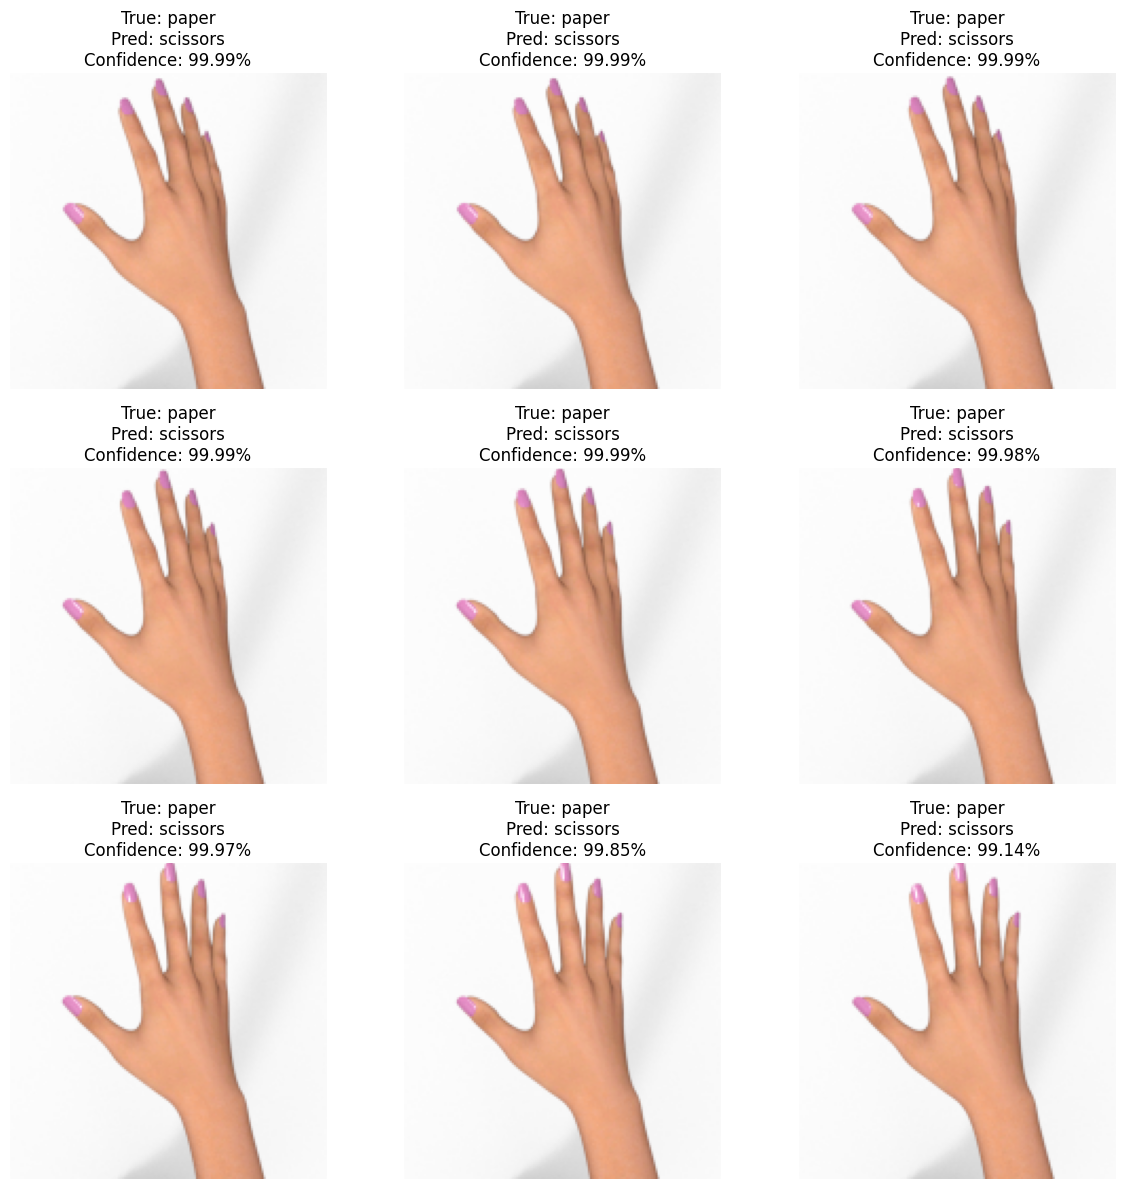

In [26]:
plt.figure(
    figsize=(12, 12)
)


for images, labels in test_ds.take(1):

    predictions = improved_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )


    for i in range(9):

        plt.subplot(
            3,
            3,
            i + 1
        )

        plt.imshow(
            images[i]
            .numpy()
            .astype("uint8")
        )


        true_label = class_names[
            labels[i]
        ]


        predicted_label = class_names[
            predicted_labels[i]
        ]


        confidence = np.max(
            predictions[i]
        )


        plt.title(
            f"True: {true_label}\n"
            f"Pred: {predicted_label}\n"
            f"Confidence: {confidence:.2%}"
        )

        plt.axis("off")


plt.tight_layout()
plt.show()

In [27]:
MODEL_PATH = "/content/rps_cnn_model.keras"

improved_model.save(
    MODEL_PATH
)

print(
    "Model saved:",
    MODEL_PATH
)

Model saved: /content/rps_cnn_model.keras


Saving RPS (1).jpg to RPS (1).jpg
Saving RPS (2).jpg to RPS (2).jpg
Saving RPS (3).jpg to RPS (3).jpg
Saving RPS (4).jpg to RPS (4).jpg
Saving RPS (5).jpg to RPS (5).jpg
Saving RPS (6).jpg to RPS (6).jpg
Saving RPS (7).jpg to RPS (7).jpg
Saving RPS (8).jpg to RPS (8).jpg
Saving RPS (9).jpg to RPS (9).jpg
Saving RPS (10).jpg to RPS (10).jpg
Saving RPS (11).jpg to RPS (11).jpg
Saving RPS (12).jpg to RPS (12).jpg
Saving RPS (13).jpg to RPS (13).jpg
Saving RPS (14).jpg to RPS (14).jpg
Saving RPS (15).jpg to RPS (15).jpg


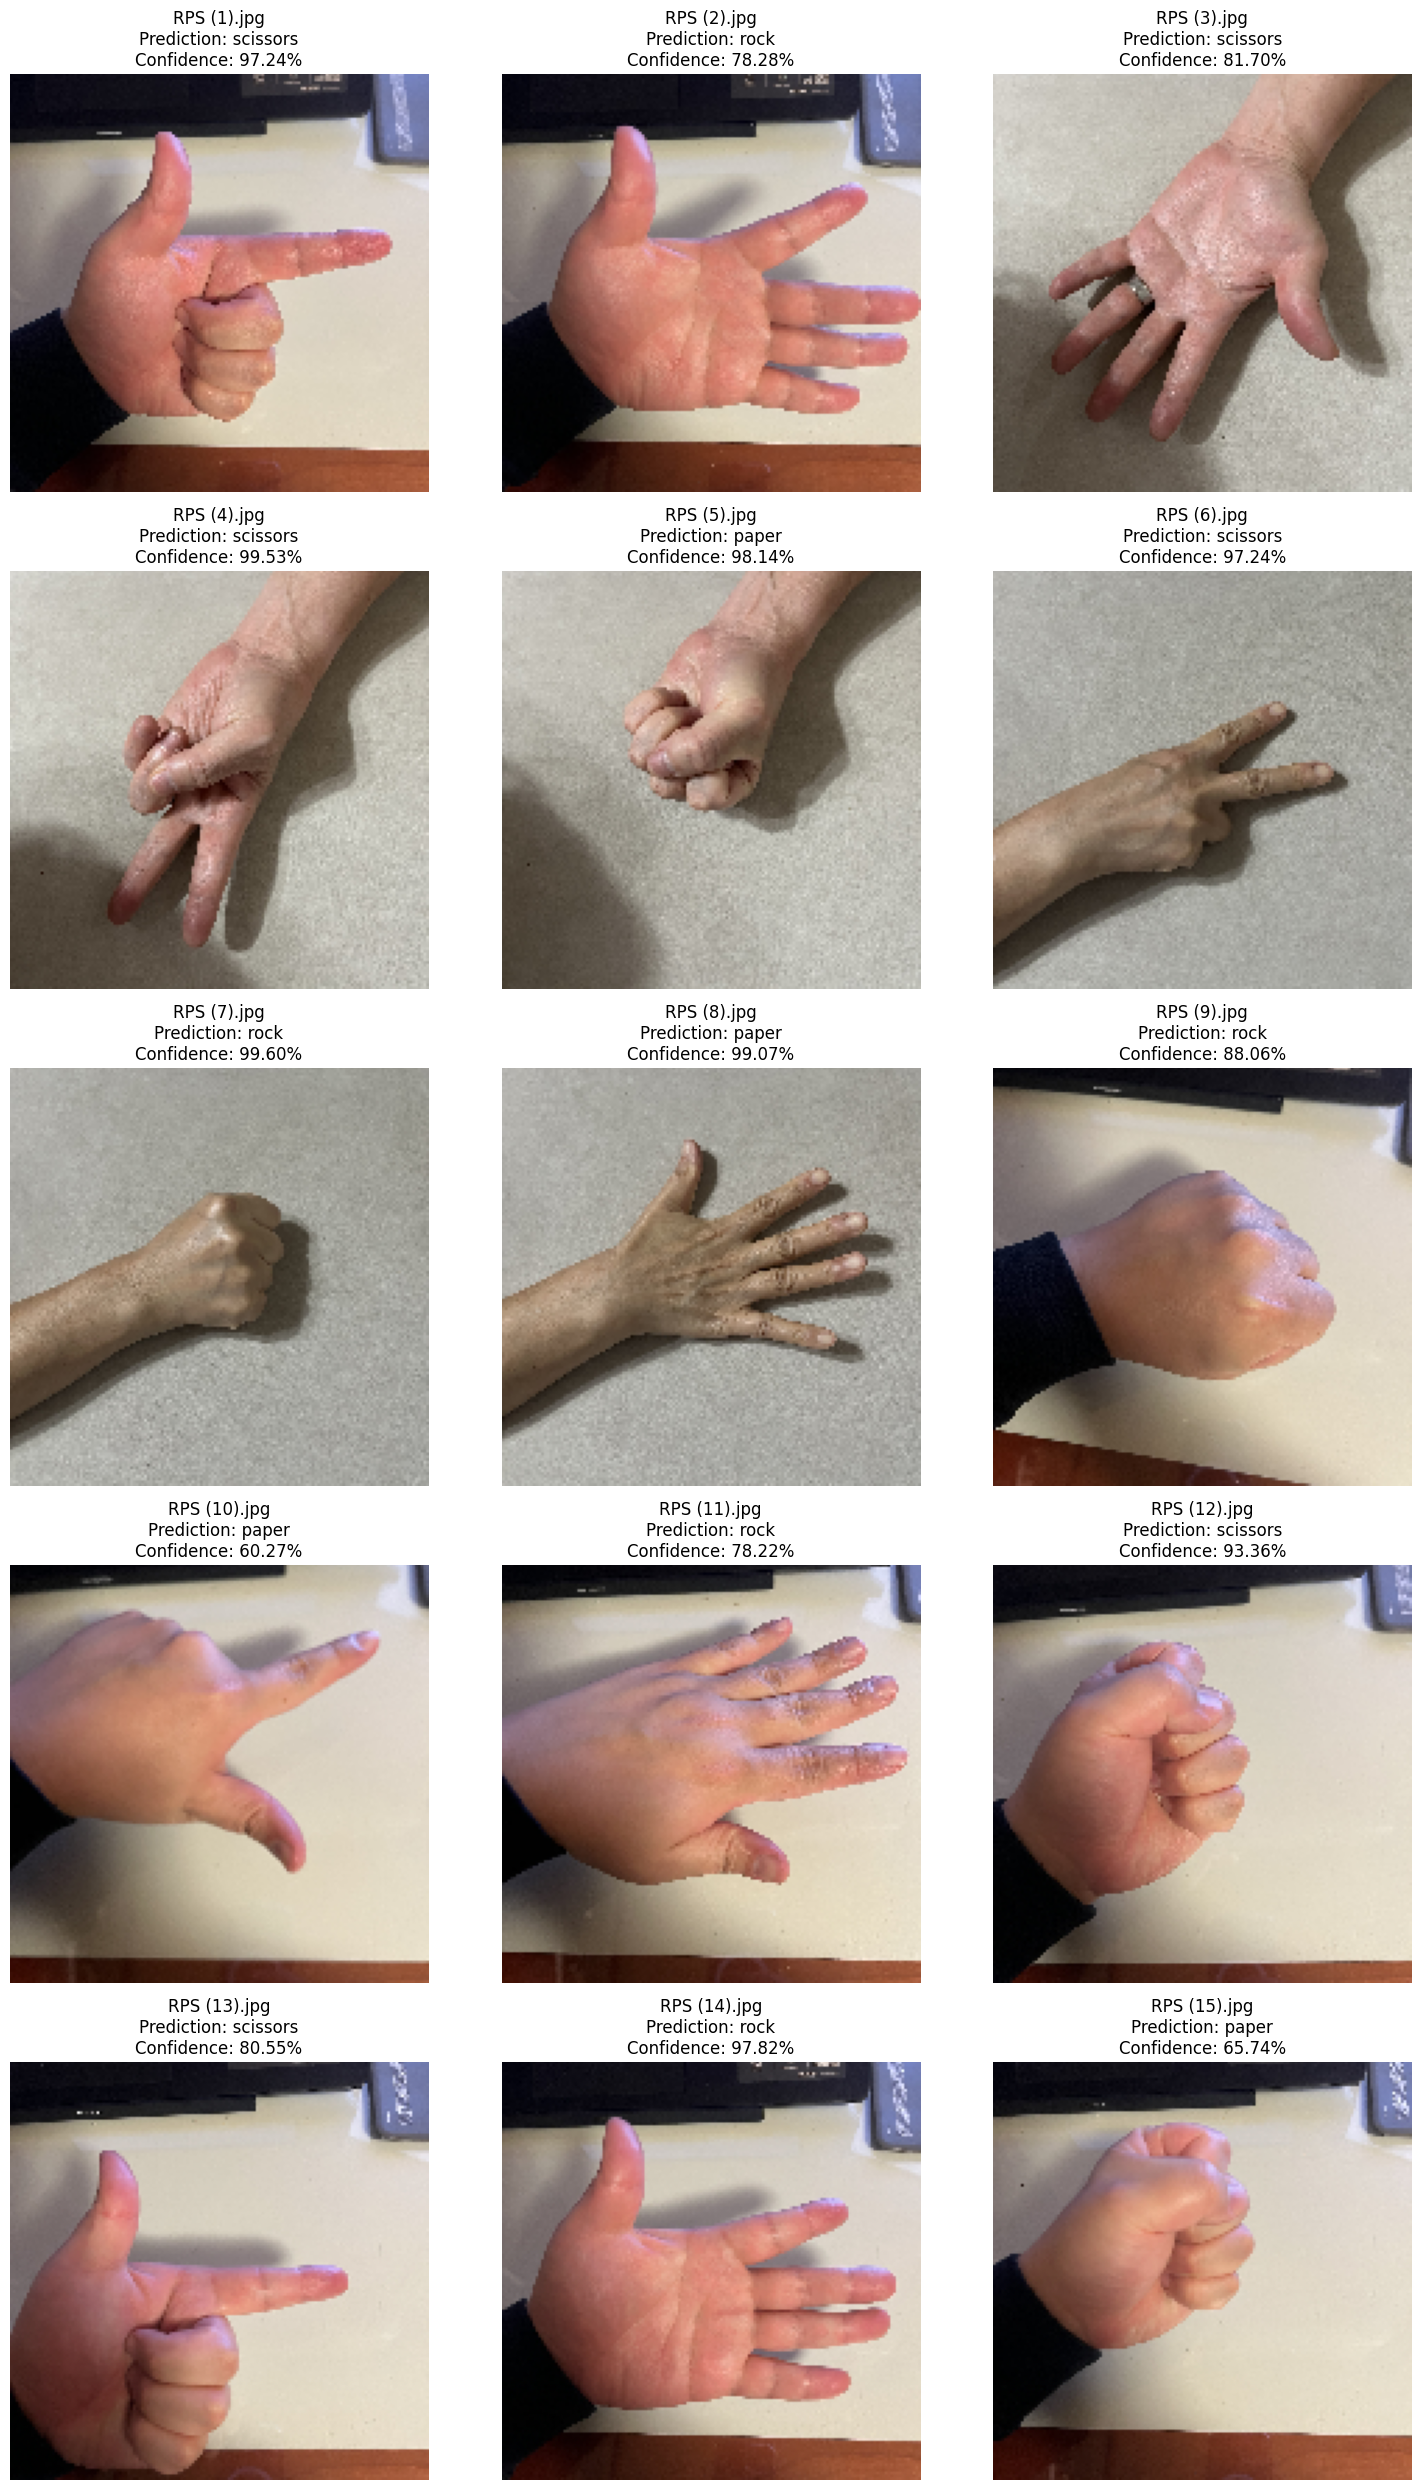


Prediction Results

File: RPS (1).jpg
Prediction: scissors
Confidence: 97.24%
Class Probabilities:
  paper     : 1.14%
  rock      : 1.62%
  scissors  : 97.24%
------------------------------------------------------------

File: RPS (2).jpg
Prediction: rock
Confidence: 78.28%
Class Probabilities:
  paper     : 0.36%
  rock      : 78.28%
  scissors  : 21.36%
------------------------------------------------------------

File: RPS (3).jpg
Prediction: scissors
Confidence: 81.70%
Class Probabilities:
  paper     : 9.90%
  rock      : 8.40%
  scissors  : 81.70%
------------------------------------------------------------

File: RPS (4).jpg
Prediction: scissors
Confidence: 99.53%
Class Probabilities:
  paper     : 0.45%
  rock      : 0.01%
  scissors  : 99.53%
------------------------------------------------------------

File: RPS (5).jpg
Prediction: paper
Confidence: 98.14%
Class Probabilities:
  paper     : 98.14%
  rock      : 0.01%
  scissors  : 1.85%
-------------------------------------

In [30]:
# ============================================================
# Predict Multiple Custom Images
# ============================================================

from google.colab import files

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras


# ------------------------------------------------------------
# 1. Upload Multiple Images
# ------------------------------------------------------------

uploaded = files.upload()


# ------------------------------------------------------------
# 2. Predict Images
# ------------------------------------------------------------

results = []

for filename in uploaded.keys():

    # 이미지 불러오기 및 크기 조정
    img = keras.utils.load_img(
        filename,
        target_size=IMG_SIZE
    )

    # 이미지 → NumPy Array
    img_array = keras.utils.img_to_array(img)

    # (150, 150, 3) → (1, 150, 150, 3)
    img_batch = np.expand_dims(
        img_array,
        axis=0
    )

    # 예측
    predictions = improved_model.predict(
        img_batch,
        verbose=0
    )[0]

    # 가장 높은 확률의 클래스
    predicted_index = np.argmax(predictions)

    predicted_class = class_names[
        predicted_index
    ]

    confidence = predictions[
        predicted_index
    ]

    # 결과 저장
    results.append({
        "filename": filename,
        "image": img,
        "prediction": predicted_class,
        "confidence": confidence,
        "probabilities": predictions
    })


# ------------------------------------------------------------
# 3. Display Predictions
# ------------------------------------------------------------

num_images = len(results)

cols = 3
rows = int(
    np.ceil(num_images / cols)
)

plt.figure(
    figsize=(15, 5 * rows)
)


for i, result in enumerate(results):

    plt.subplot(
        rows,
        cols,
        i + 1
    )

    plt.imshow(
        result["image"]
    )

    plt.title(
        f"{result['filename']}\n"
        f"Prediction: {result['prediction']}\n"
        f"Confidence: {result['confidence']:.2%}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Print Detailed Probabilities
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Prediction Results")
print("=" * 60)


for result in results:

    print(
        f"\nFile: {result['filename']}"
    )

    print(
        f"Prediction: {result['prediction']}"
    )

    print(
        f"Confidence: {result['confidence']:.2%}"
    )

    print("Class Probabilities:")

    for class_name, probability in zip(
        class_names,
        result["probabilities"]
    ):

        print(
            f"  {class_name:10s}: "
            f"{probability:.2%}"
        )

    print("-" * 60)